In [24]:
using Revise
includet("functions.jl")
using .MyFunctions

using LinearAlgebra
using QuantumToolbox
using ProgressMeter
using CairoMakie

CairoMakie.activate!(type = "png", px_per_unit = 2)

set_theme!(merge(theme_latexfonts(),
    Theme(
        size           = (800, 500),
        fontsize       = 20,
        figure_padding = 14,
        Axis = (
            xgridvisible = false,
            ygridvisible = false,
            xtickalign   = 0,
            ytickalign   = 0,
            xlabelsize     = 24,
            ylabelsize     = 24,
            xticklabelsize = 20,
            yticklabelsize = 20,
        ),
        Lines = (linewidth = 3,),
    ),
))

# Hermitian case

## $N=1$ qubit

In [32]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 1

vars = (ωa=ωa,
    ωb=ωb,
    Nc=Nc,
    N=N
);

In [33]:
g_list = range(1e-3, 3, 200) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


  0.323759 seconds (287.84 k allocations: 120.799 MiB, 15.09% gc time, 14.40% compilation time)
  0.439478 seconds (280.82 k allocations: 202.431 MiB, 11.10% gc time, 11.74% compilation time)
  0.410004 seconds (194.57 k allocations: 249.421 MiB, 11.81% gc time, 13.07% compilation time)


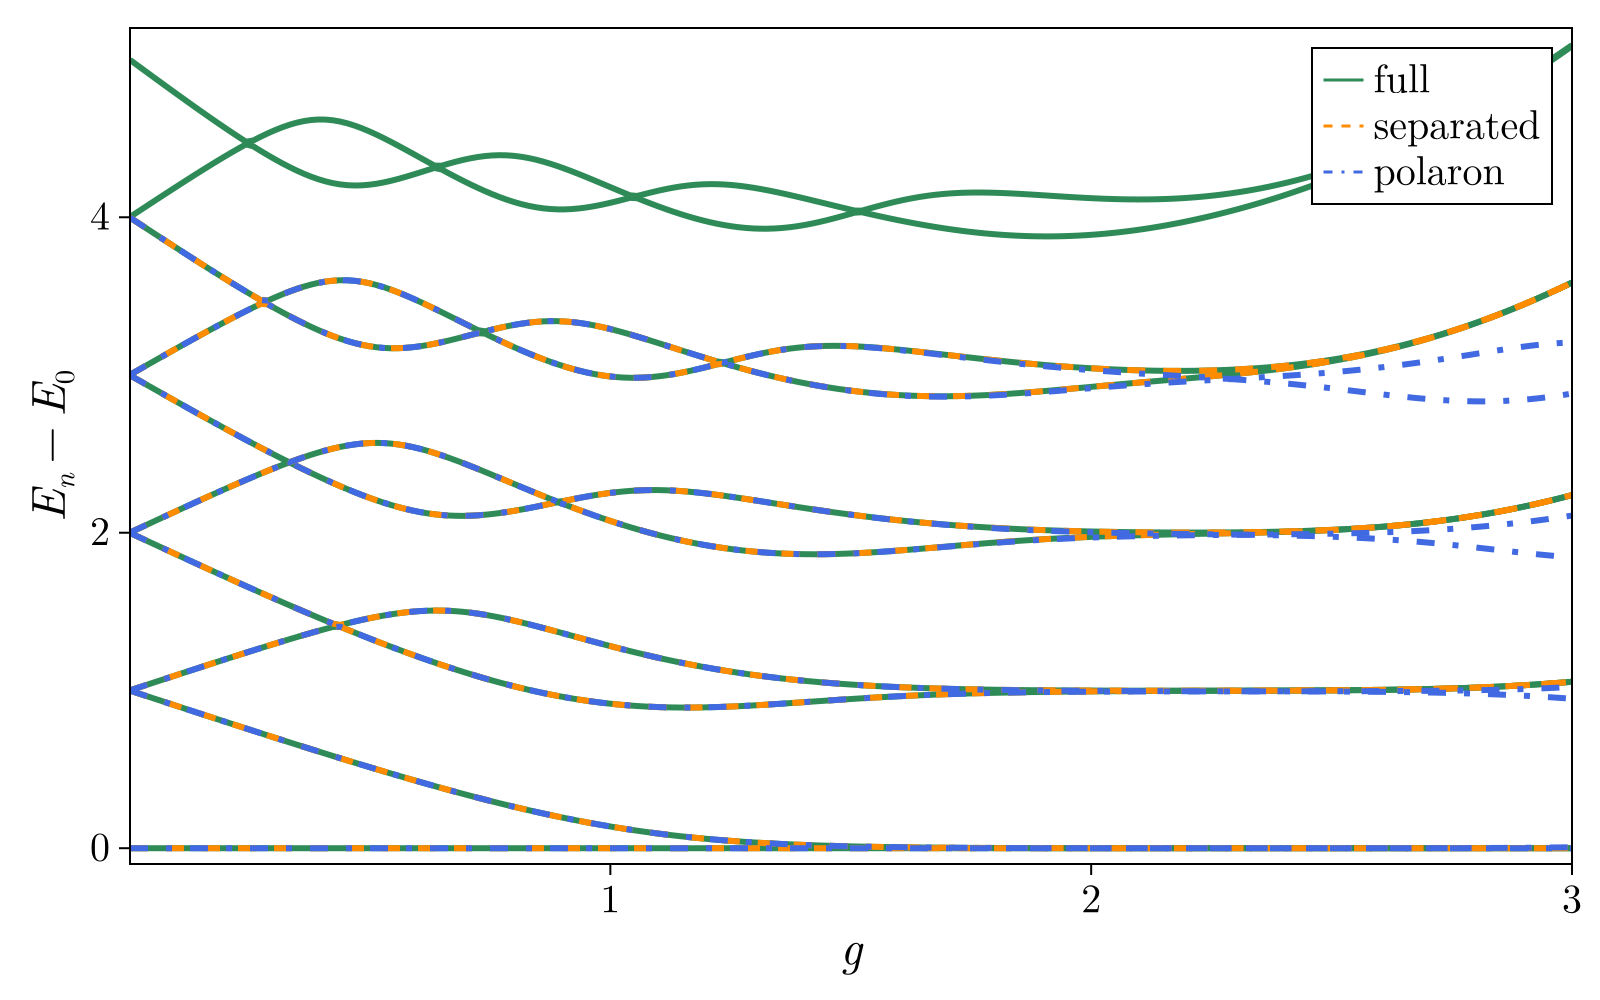

In [34]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

save("QRM_energies_1at.pdf", fig; px_per_unit = 3)
fig

## $N=2$ qubits

In [28]:
ωa = 1.0
ωb = 1.0
Nc = 20
N = 2

vars = (ωa=ωa,
    ωb=ωb,
    Nc=Nc,
    N=N
);

In [29]:
g_list = range(1e-3, 3, 200) |> collect

neigs = 40

vals_full = similar(g_list, length(g_list), neigs)
fill!(vals_full, NaN)

Prog = Progress(length(g_list))
@time Threads.@threads for i in eachindex(g_list)
    vals_full[i,:] = get_shifted_eigvals(H_Dicke(g_list[i], vars), neigs, -1000, 1e-16)
    next!(Prog)
end

nel = 4    # eigenvalues kept per block, (N+3-2*j)*nel
nj = Int64(floor(N/2+1))
neigs = [Int64((N+1-2*i)*nel) for i in 0:nj-1]
vals_sep = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_sep, NaN)

H_0_sep, H_int_sep = H_comp_separated(vars)
@time Threads.@threads for i in eachindex(g_list)
    H_Dicke = H_Dicke_separated(H_0_sep, H_int_sep, g_list[i])
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_sep[j,i,1:neigs_j] .= real.(prov.values)
    end
end

vals_polaron = similar(g_list, nj, length(g_list), maximum(neigs))
fill!(vals_polaron, NaN)

@time Threads.@threads for i in eachindex(g_list)
    for j in 1:nj
        neigs_j = neigs[j]
        prov = eigsolve(H_Dicke_polaron(g_list[i], vars)[j], eigvals=neigs_j, sigma=-1000, tol=1e-16)
        vals_polaron[j,i,1:neigs_j] .= real.(prov.values)
    end
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:03


  3.515982 seconds (1.79 M allocations: 379.016 MiB, 1.89% gc time, 14.98% compilation time)
  1.075486 seconds (514.05 k allocations: 393.639 MiB, 6.36% gc time, 5.10% compilation time)
  1.035304 seconds (398.49 k allocations: 633.836 MiB, 8.03% gc time, 5.06% compilation time)


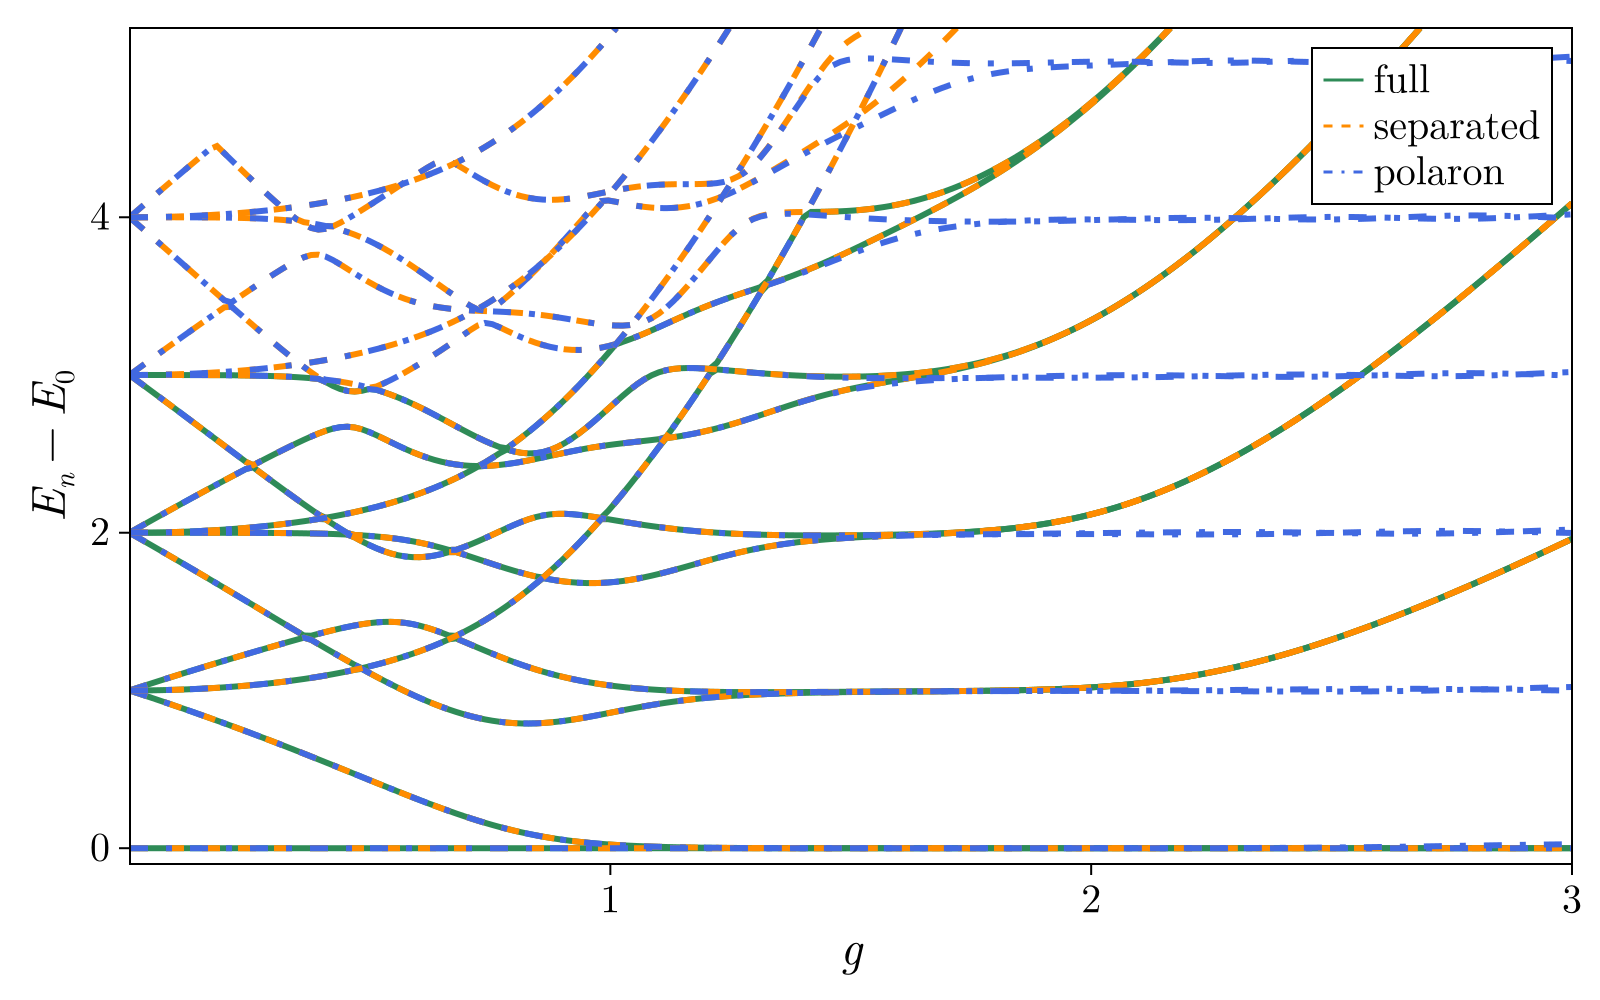

In [31]:
fig = Figure()
ax = Axis(fig[1, 1]; xlabel = L"g", ylabel = L"E_n - E_0", limits = ((g_list[1], g_list[end]), (-0.1, 5.2)))

for i in 1:10
    lines!(ax, g_list, vals_full[:, i]; color = :seagreen)
end

for i in 1:nj
    for k in axes(vals_sep, 3)
        lines!(ax, g_list, vals_sep[i, :, k] .- vals_sep[1, :, 1]; color = :darkorange, linestyle = :dash)
    end
    for k in axes(vals_polaron, 3)
        lines!(ax, g_list, vals_polaron[i, :, k] .- vals_polaron[1, :, 1]; color = :royalblue, linestyle = :dashdot)
    end
end

Legend(fig[1, 1],
    [LineElement(color = :seagreen),
     LineElement(color = :darkorange, linestyle = :dash),
     LineElement(color = :royalblue, linestyle = :dashdot)],
    ["full", "separated", "polaron"];
    tellwidth = false, tellheight = false,
    halign = :right, valign = :top, margin = (10, 10, 10, 10)
)

save("QRM_energies_2at.pdf", fig; px_per_unit = 3)
fig